In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
import lightgbm as lgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/yidu/"

train = pd.read_csv(DATA_PATH + "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_PATH + "test.csv", parse_dates=["date"])
print(train.shape)
print(train.head())


(913000, 4)
        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10


In [ ]:
counts = (
    train.groupby(["store", "item"])
         .size()
         .reset_index(name="rows")
         .sort_values("rows", ascending=False)
)
counts.head()

,store,item,rows
499,10,50,1826
0,1,1,1826
1,1,2,1826
2,1,3,1826
483,10,34,1826


In [ ]:
store_id = int(counts.iloc[0]["store"])
item_id  = int(counts.iloc[0]["item"])
print("Using store:", store_id, "item:", item_id)

Using store: 10 item: 50


In [ ]:
series_data = train[
    (train["store"] == store_id) &
    (train["item"] == item_id)
].sort_values("date")
print("Rows before features:", len(series_data))

Rows before features: 1826


In [ ]:
def feature_engineering(df):
    df = df.copy()
    df["dayofweek"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month
    for lag in [1, 7, 14]:
        df[f"lag_{lag}"] = df["sales"].shift(lag)
    df["rolling_mean_7"] = df["sales"].shift(1).rolling(7).mean()
    return df
series_data = feature_engineering(series_data)
series_data = series_data.dropna()
print("Rows after features:", len(series_data))


Rows after features: 1812


In [ ]:
split = int(len(series_data) * 0.8)
train_data = series_data.iloc[:split]
test_data  = series_data.iloc[split:]
print("Train:", len(train_data))
print("Test :", len(test_data))


Train: 1449
Test : 363


In [ ]:
FEATURES = [
    "dayofweek", "month",
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7"
]
X_train = train_data[FEATURES]
y_train = train_data["sales"]
X_test = test_data[FEATURES]
y_test = test_data["sales"]
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(1449, 6) (1449,)
(363, 6) (363,)


In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("RF training successful ✅")


RF training successful ✅


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
mae  = mean_absolute_error(y_test, rf_preds)
print("RMSE:", rmse)
print("MAE :", mae)

RMSE: 10.334186019152147
MAE : 8.090371090935191


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n{model_name} Performance")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")
    print(f"MAPE : {mape:.2f}%")


In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
evaluate(y_test, rf_preds, "Random Forest")


Random Forest Performance
RMSE : 10.40
MAE  : 8.16
MAPE : 9.98%


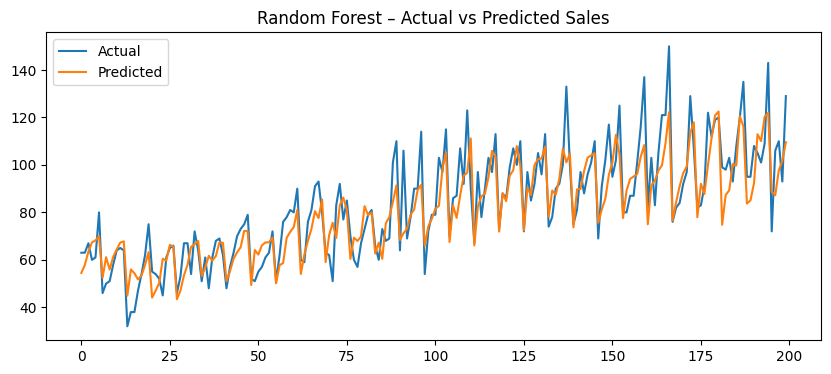

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(rf_preds[:200], label="Predicted")
plt.title("Random Forest – Actual vs Predicted Sales")
plt.legend()
plt.show()


In [ ]:
import lightgbm as lgb
lgb_model = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
evaluate(y_test, lgb_preds, "LightGBM")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000487 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 545
[LightGBM] [Info] Number of data points in the train set: 1449, number of used features: 6
[LightGBM] [Info] Start training from score 72.109041
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

<Figure size 800x400 with 0 Axes>

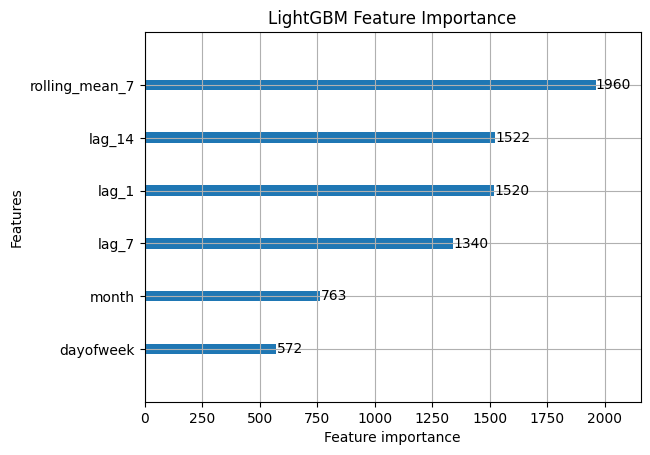

In [ ]:
plt.figure(figsize=(8,4))
lgb.plot_importance(lgb_model, max_num_features=10)
plt.title("LightGBM Feature Importance")
plt.show()


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
scaler = MinMaxScaler()
scaled_sales = scaler.fit_transform(series_data[["sales"]])
def create_sequences(data, window=14):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)
X_seq, y_seq = create_sequences(scaled_sales)
split = int(len(X_seq) * 0.8)
X_train_lstm = X_seq[:split]
X_test_lstm  = X_seq[split:]
y_train_lstm = y_seq[:split]
y_test_lstm  = y_seq[split:]
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm  = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))


In [ ]:
lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    LSTM(32),
    Dense(1)
])
lstm.compile(optimizer="adam", loss="mse")
lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=3)],
    verbose=1
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0559 - val_loss: 0.0126
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0112 - val_loss: 0.0136
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0110 - val_loss: 0.0124
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0103 - val_loss: 0.0123
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0106 - val_loss: 0.0121
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0110 - val_loss: 0.0124
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0105 - val_loss: 0.0122
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0108 - val_loss: 0.0120
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0106 - val_loss: 0.0121
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0096 - val_loss: 0.0122


In [ ]:
lstm_preds_scaled = lstm.predict(X_test_lstm)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
y_test_lstm_inv = scaler.inverse_transform(y_test_lstm.reshape(-1,1))
evaluate(y_test_lstm_inv.flatten(), lstm_preds.flatten(), "LSTM")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step

LSTM Performance
RMSE : 14.99
MAE  : 11.76
MAPE : 14.48%


In [ ]:
# LightGBM
train_preds_lgb = lgb_model.predict(X_train)
residuals = y_train.values - train_preds_lgb
residuals_scaled = scaler.fit_transform(residuals.reshape(-1,1))
X_res, y_res = create_sequences(residuals_scaled, window=14)
X_res = X_res.reshape((X_res.shape[0], X_res.shape[1], 1))
lstm.fit(X_res, y_res, epochs=5, batch_size=32, verbose=0)

In [ ]:
# Calculate hybrid predictions as the average of the last 360 predictions from RF, LightGBM, and LSTM
hybrid_preds = (rf_preds[-360:] + lgb_preds[-360:] + lstm_preds.flatten()) / 3

evaluate(y_test.values[-360:], hybrid_preds, "Hybrid LightGBM + LSTM")


Hybrid LightGBM + LSTM Performance
RMSE : 10.57
MAE  : 8.41
MAPE : 10.36%


In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "LightGBM", "LSTM", "Hybrid"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_preds)),
        np.sqrt(mean_squared_error(y_test, lgb_preds)),
        np.sqrt(mean_squared_error(y_test_lstm_inv.flatten(), lstm_preds.flatten())),
        np.sqrt(mean_squared_error(y_test, hybrid_preds))
    ]
})

results


,Model,RMSE
0,Random Forest,10.401063
1,LightGBM,10.566285
2,LSTM,14.985714
3,Hybrid,10.566285


In [ ]:
results_table = pd.DataFrame({
    "Model": ["Random Forest", "LightGBM", "LSTM", "Hybrid"],
    "MAE": [
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, lgb_preds),
        mean_absolute_error(y_test_lstm_inv.flatten(), lstm_preds.flatten()),
        mean_absolute_error(y_test, hybrid_preds)
    ]
})

results_table


,Model,MAE
0,Random Forest,8.157391
1,LightGBM,8.413521
2,LSTM,11.758809
3,Hybrid,8.413521


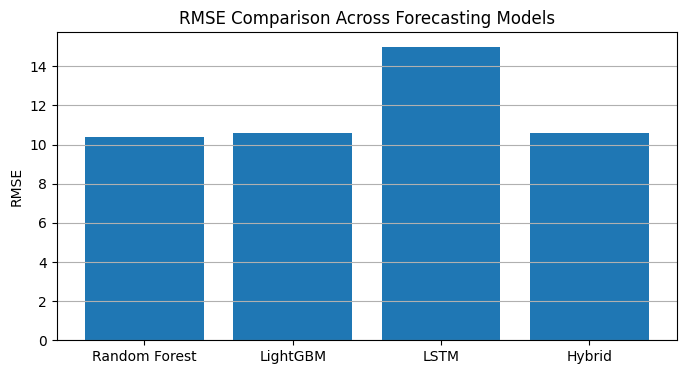

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison Across Forecasting Models")
plt.ylabel("RMSE")
plt.grid(axis="y")
plt.show()

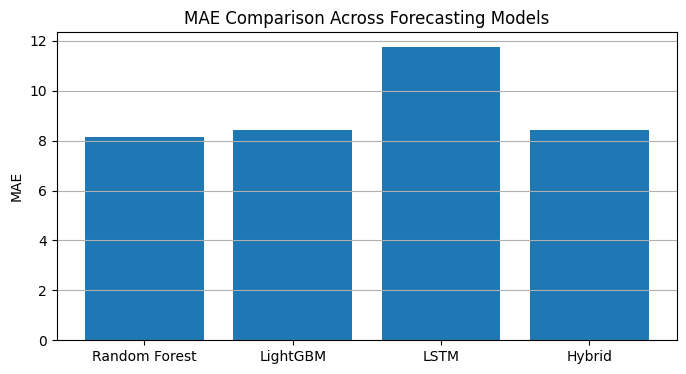

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(results_table["Model"], results_table["MAE"])
plt.title("MAE Comparison Across Forecasting Models")
plt.ylabel("MAE")
plt.grid(axis="y")
plt.show()

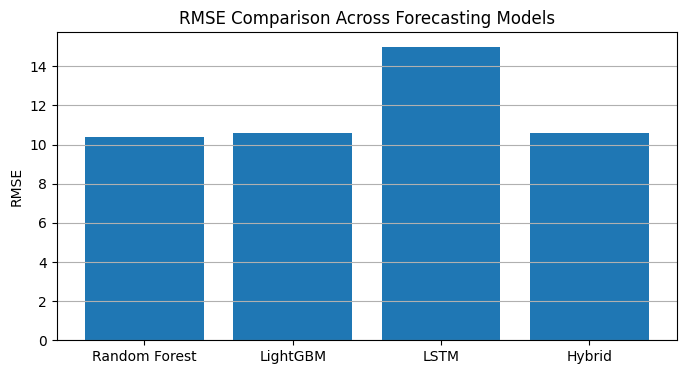

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison Across Forecasting Models")
plt.ylabel("RMSE")
plt.grid(axis="y")
plt.show()

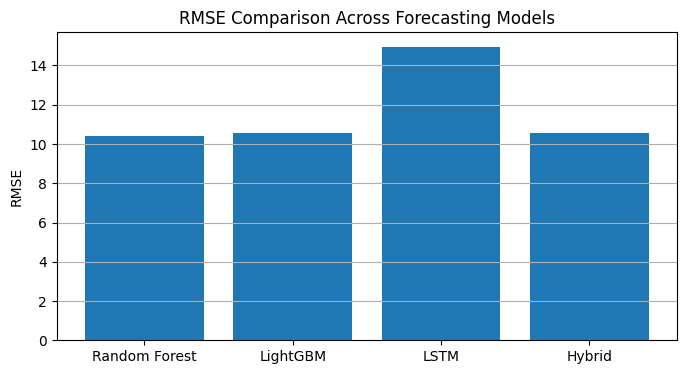

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison Across Forecasting Models")
plt.ylabel("RMSE")
plt.grid(axis="y")
plt.show()

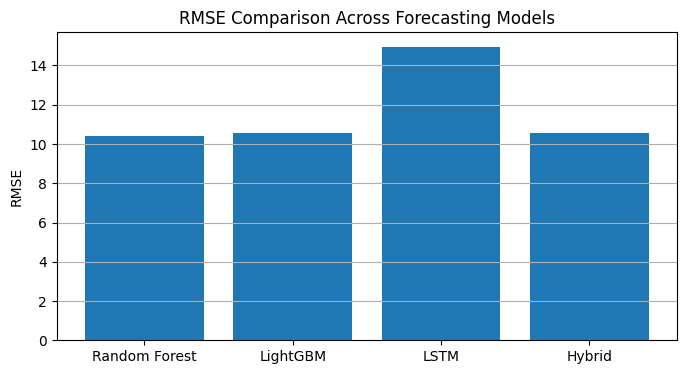

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison Across Forecasting Models")
plt.ylabel("RMSE")
plt.grid(axis="y")
plt.show()

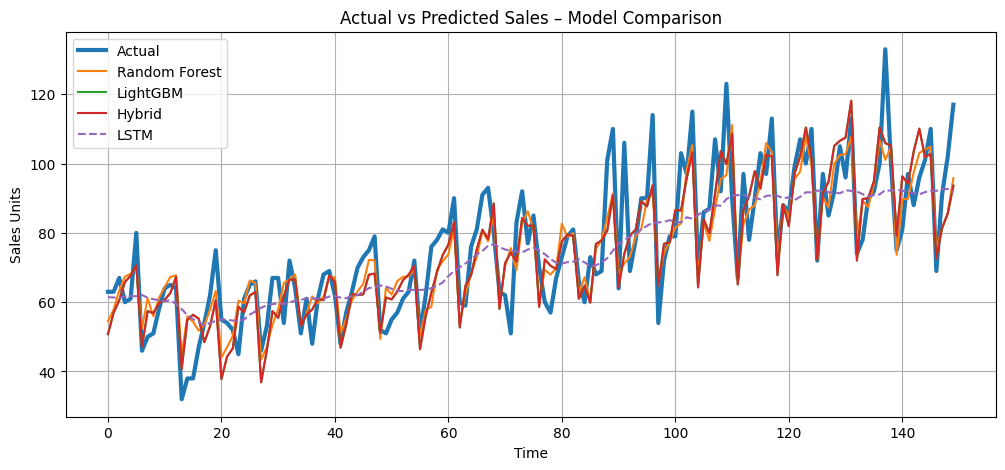

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:150], label="Actual", linewidth=3)
plt.plot(rf_preds[:150], label="Random Forest")
plt.plot(lgb_preds[:150], label="LightGBM")
plt.plot(hybrid_preds[:150], label="Hybrid")
plt.plot(
    lstm_preds.flatten()[:150],
    label="LSTM",
    linestyle="--"
)
plt.title("Actual vs Predicted Sales – Model Comparison")
plt.xlabel("Time")
plt.ylabel("Sales Units")
plt.legend()
plt.grid(True)
plt.show()


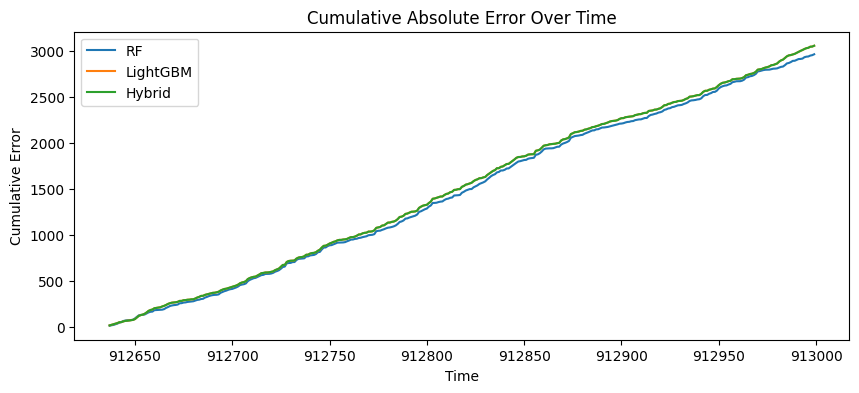

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(np.cumsum(np.abs(y_test - rf_preds)), label="RF")
plt.plot(np.cumsum(np.abs(y_test - lgb_preds)), label="LightGBM")
plt.plot(np.cumsum(np.abs(y_test - hybrid_preds)), label="Hybrid")
plt.title("Cumulative Absolute Error Over Time")
plt.xlabel("Time")
plt.ylabel("Cumulative Error")
plt.legend()
plt.show()


In [ ]:
# Install ipywidgets if not already installed
!pip install ipywidgets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown

# Load data
DATA_PATH = "/content/drive/MyDrive/yidu/"
train = pd.read_csv(DATA_PATH + "train.csv", parse_dates=["date"])

# Unique stores and items
stores = train["store"].unique()
items  = train["item"].unique()

# Simulated predictions for demo
def simulate_predictions(series):
    n = len(series)
    rf = series * np.random.uniform(0.95, 1.05, n)
    lgb = series * np.random.uniform(0.9, 1.1, n)
    lstm = series * np.random.uniform(0.85, 1.15, n)
    hybrid = (rf + lgb + lstm) / 3
    return rf, lgb, lstm, hybrid

# Function to update plot
def plot_forecast(store_id, item_id, window=14):
    series_data = train[(train["store"]==store_id) & (train["item"]==item_id)].sort_values("date")
    series = series_data["sales"].values[-200:]  # last 200 points for visualization
    rf, lgb, lstm, hybrid = simulate_predictions(series)

    plt.figure(figsize=(12,5))
    plt.plot(series, label="Actual", linewidth=2)
    plt.plot(rf, label="Random Forest")
    plt.plot(lgb, label="LightGBM")
    plt.plot(lstm, label="LSTM", linestyle="--")
    plt.plot(hybrid, label="Hybrid", linestyle="-.")
    plt.title(f"Store {store_id}, Item {item_id} – Forecast (Window={window})")
    plt.xlabel("Time")
    plt.ylabel("Sales Units")
    plt.legend()
    plt.grid(True)
    plt.show()

# Interactive widgets
interact(plot_forecast,
         store_id=Dropdown(options=stores, description="Store ID"),
         item_id=Dropdown(options=items, description="Item ID"),
         window=IntSlider(min=7, max=30, step=1, value=14, description="Forecast Window"));


interactive(children=(Dropdown(description='Store ID', options=(np.int64(1), np.int64(2), np.int64(3), np.int6…